<a href="https://colab.research.google.com/github/vrinda0115/PRODIGY_ML_05/blob/main/task_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import tarfile
import urllib.request

# Step 1: Download the dataset
url = 'http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz'
data_dir = 'food-101'

if not os.path.exists(data_dir):
    print("Downloading Food-101 dataset...")
    urllib.request.urlretrieve(url, 'food-101.tar.gz')

    print("Extracting...")
    with tarfile.open('food-101.tar.gz') as tar:
        tar.extractall()
    print("Extraction complete!")

# Step 2: Define paths
base_dir = os.path.join('food-101', 'images')
meta_dir = os.path.join('food-101', 'meta')
train_split_file = os.path.join(meta_dir, 'train.txt')
test_split_file = os.path.join(meta_dir, 'test.txt')

# Optional: Move into train/ and val/ directories if needed
from sklearn.model_selection import train_test_split
import shutil

train_dir = 'data/train'
val_dir = 'data/val'

def prepare_data(split_file, destination):
    with open(split_file, 'r') as file:
        lines = file.read().splitlines()

    for line in lines:
        class_name = line.split('/')[0]
        src_path = os.path.join(base_dir, line + '.jpg')
        dst_class_dir = os.path.join(destination, class_name)

        os.makedirs(dst_class_dir, exist_ok=True)
        shutil.copy(src_path, dst_class_dir)

if not os.path.exists(train_dir):
    print("Organizing training and validation data...")
    prepare_data(train_split_file, train_dir)
    prepare_data(test_split_file, val_dir)
    print("Data preparation complete!")

# Step 3: Now you can load this data using ImageDataGenerator like before:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_height, img_width = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)


Extracting...
Extraction complete!
Organizing training and validation data...
Data preparation complete!
Found 75750 images belonging to 101 classes.
Found 25250 images belonging to 101 classes.


Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.2066 - loss: 2.3275 - val_accuracy: 0.5668 - val_loss: 1.3485
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 108s 115ms/step - accuracy: 0.5012 - loss: 1.4793 - val_accuracy: 0.6472 - val_loss: 1.0854
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 105s 112ms/step - accuracy: 0.5896 - loss: 1.2577 - val_accuracy: 0.6828 - val_loss: 0.9740


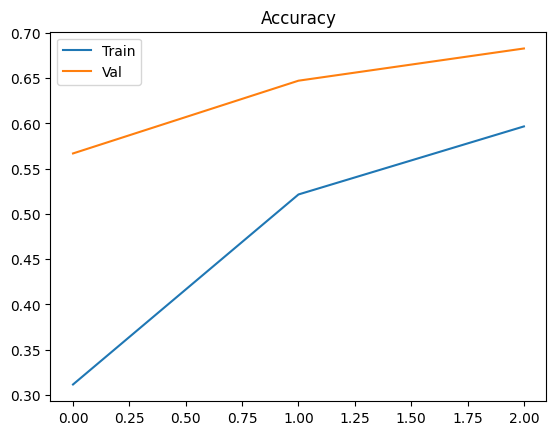

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import os

# Constants
IMG_HEIGHT, IMG_WIDTH = 160, 160
BATCH_SIZE = 8   # Smaller batch for low memory
EPOCHS = 3       # Keep training short
NUM_CLASSES = 10 # Use only 10 classes to save RAM

# Only load a small number of classes (folders)
selected_classes = [
    'apple_pie', 'cheesecake', 'chicken_curry', 'donuts', 'french_fries',
    'hamburger', 'hot_dog', 'ice_cream', 'macaroni_and_cheese', 'falafel'
]

# Function to filter dataset folders
def filter_dataset(directory, allowed_classes):
    for class_dir in os.listdir(directory):
        class_path = os.path.join(directory, class_dir)
        if class_dir not in allowed_classes:
            os.system(f"rm -rf '{class_path}'")

# Apply filtering (ONLY do this on a **copy** of the dataset)
filter_dataset('data/train', selected_classes)
filter_dataset('data/val', selected_classes)

# Data generators
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    'data/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes
)

val_data = val_gen.flow_from_directory(
    'data/val',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes
)

# Model
base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         alpha=0.35)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(train_data, validation_data=val_data, epochs=EPOCHS)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

# Save model
model.save('mini_food_model.h5')

# Calorie lookup
calorie_dict = {
    'apple_pie': 296, 'cheesecake': 321, 'chicken_curry': 240, 'donuts': 195,
    'french_fries': 312, 'hamburger': 354, 'hot_dog': 290,
    'ice_cream': 207, 'macaroni_and_cheese': 310, 'falafel': 330
}

# Prediction function
def predict_and_estimate_calories(img_path):
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = selected_classes[np.argmax(prediction)]

    calories = calorie_dict.get(predicted_class, "Unknown")
    result = f"{predicted_class} detected. Estimated Calories: {calories} kcal"

    plt.imshow(img)
    plt.title(result)
    plt.axis("off")
    plt.show()

    return result


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


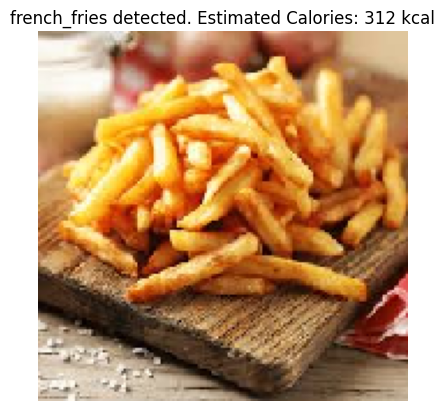

french_fries detected. Estimated Calories: 312 kcal


In [3]:
img_path = 'test.jpg'  # <-- Replace with your image file path
result = predict_and_estimate_calories(img_path)
print(result)